<a href="https://colab.research.google.com/github/Vikram4405/Context-Aware-Health/blob/main/ECG_Reconstruction_Model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, time, gc, glob, pickle
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python:  {sys.version.split()[0]}")
print(f"NumPy:   {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device:  {DEVICE}")

Python:  3.13.15
NumPy:   2.1.3
PyTorch: 2.11.0+cu128
Device:  cuda


In [ ]:
# ==============================================================================
# CELL 3: DSP PREPROCESSING, ACC SQI & TIME-FREQUENCY SPECTROGRAMS
# ==============================================================================

def butterworth_bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(1e-4, lowcut / nyq)
    high = min(0.9999, highcut / nyq)
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def filter_signal_sos(data, sos, axis=-1):
    if not np.all(np.isfinite(data)):
        raise ValueError("Input signal contains non-finite values (NaN or Inf).")
    padlen = min(data.shape[axis] // 2, 100)
    filtered = signal.sosfiltfilt(sos, data, axis=axis, padtype="odd", padlen=padlen)
    return np.ascontiguousarray(filtered, dtype=np.float32)

def filter_ppg(ppg, fs=64.0, lowcut=0.5, highcut=8.0, order=4):
    sos = butterworth_bandpass_sos(lowcut, highcut, fs, order=order)
    return filter_signal_sos(ppg, sos)

def filter_ecg(ecg, fs=128.0, lowcut=0.5, highcut=40.0, order=4):
    sos = butterworth_bandpass_sos(lowcut, highcut, fs, order=order)
    return filter_signal_sos(ecg, sos)

def compute_acc_sqi(acc, theta_acc=0.05, threshold=None):
    if threshold is not None:
        theta_acc = threshold
    acc_arr = np.asarray(acc, dtype=np.float32)
    if acc_arr.ndim == 2:
        if acc_arr.shape[1] == 3:
            var_components = np.var(acc_arr, axis=0)
        elif acc_arr.shape[0] == 3:
            var_components = np.var(acc_arr, axis=1)
        else:
            raise ValueError(f"Expected 3 accelerometer axes, got {acc_arr.shape}")
    else:
        return True, 0.0
    total_var = float(np.sum(var_components))
    is_clean = bool(total_var <= theta_acc)
    return is_clean, total_var

def zscore_normalize(x, eps=1e-8):
    if isinstance(x, torch.Tensor):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return (x - mean) / (std + eps)
    else:
        arr = np.asarray(x, dtype=np.float32)
        mean = np.mean(arr, axis=-1, keepdims=True)
        std = np.std(arr, axis=-1, keepdims=True)
        return (arr - mean) / (std + eps)


class PPGToSpectrogramCWT(nn.Module):
    """Pure PyTorch Morlet CWT: (B, 1, L) -> (B, 1, 64, L)"""
    def __init__(self, fs=64.0, num_scales=64, f_min=0.5, f_max=8.0, w0=6.0):
        super().__init__()
        self.fs = fs
        self.num_scales = num_scales
        self.w0 = w0
        freqs = torch.linspace(f_min, f_max, num_scales)
        scales = (w0 * fs) / (2.0 * np.pi * freqs)
        self.register_buffer("scales", scales)
        self.register_buffer("freqs", freqs)

    def forward(self, x):
        if x.ndim == 3:
            x = x.squeeze(1)
        B, L = x.shape
        if L <= 0:
            raise ValueError("Input sequence length must be positive.")
        device, dtype = x.device, x.dtype

        N_padded = 2 ** int(np.ceil(np.log2(2 * L)))
        k = torch.fft.fftfreq(N_padded, d=1.0 / self.fs).to(device=device, dtype=dtype)
        x_fft = torch.fft.fft(x.unsqueeze(1), n=N_padded, dim=-1)

        s = self.scales.view(1, self.num_scales, 1)
        k_grid = k.view(1, 1, N_padded)

        psi_hat = (
            (np.pi ** -0.25) * torch.sqrt(s)
            * torch.exp(-0.5 * ((2.0 * np.pi * s * k_grid - self.w0) ** 2))
            * (k_grid > 0.0).to(dtype)
        )

        cwt_coeffs = torch.fft.ifft(x_fft * psi_hat, dim=-1)[..., :L]
        mag = torch.abs(cwt_coeffs)
        log_mag = torch.log1p(mag)
        min_v = log_mag.amin(dim=(-2, -1), keepdim=True)
        max_v = log_mag.amax(dim=(-2, -1), keepdim=True)
        norm_mag = (log_mag - min_v) / (max_v - min_v + 1e-8)
        return norm_mag.unsqueeze(1)

print("✅ Cell 3: DSP & Spectrogram generators ready.")

✅ Cell 3: DSP & Spectrogram generators ready.


In [ ]:
# ==============================================================================
# CELL 4: SOTA 1D MULTI-SCALE DILATED RESIDUAL U-NET (ResU-Net-1D)
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock1D(nn.Module):
    """Dilated Residual Block with Gated Activation to capture multi-scale rhythms."""
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=7, padding=3 * dilation, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.act = nn.GELU()
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=7, padding=3, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)

        self.shortcut = nn.Sequential()
        if in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )

    def forward(self, x):
        res = self.shortcut(x)
        h = self.act(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        return self.act(h + res)

class PPG2ECG_ResUNet1D(nn.Module):
    """
    Direct 1D-to-1D Multi-Scale Architecture with U-Net Skip Connections.
    Preserves exact sub-millisecond phase alignment and systolic peak timing.
    """
    def __init__(self, in_channels=1, base_channels=32, target_length=1024):
        super().__init__()
        self.target_length = target_length
        bc = base_channels

        # --- Encoder (Downsampling with expanding receptive fields) ---
        self.enc1 = ConvBlock1D(in_channels, bc, dilation=1)      # L = 512
        self.down1 = nn.Conv1d(bc, bc*2, kernel_size=4, stride=2, padding=1) # L = 256

        self.enc2 = ConvBlock1D(bc*2, bc*2, dilation=2)          # L = 256
        self.down2 = nn.Conv1d(bc*2, bc*4, kernel_size=4, stride=2, padding=1) # L = 128

        self.enc3 = ConvBlock1D(bc*4, bc*4, dilation=4)          # L = 128
        self.down3 = nn.Conv1d(bc*4, bc*8, kernel_size=4, stride=2, padding=1) # L = 64

        # --- Bottleneck (Global Rhythm & PTT Tracking) ---
        self.bottleneck = nn.Sequential(
            ConvBlock1D(bc*8, bc*8, dilation=8),
            nn.Dropout(0.1)
        )
        self.gru = nn.GRU(bc*8, bc*4, batch_first=True, bidirectional=True)

        # --- Decoder (Upsampling with Skip Connections directly to Target Length 1024) ---
        # Step 1: 64 -> 128
        self.up1 = nn.ConvTranspose1d(bc*8, bc*4, kernel_size=4, stride=2, padding=1)
        self.dec1 = ConvBlock1D(bc*8, bc*4) # concat with enc3 (bc*4 + bc*4 = bc*8)

        # Step 2: 128 -> 256
        self.up2 = nn.ConvTranspose1d(bc*4, bc*2, kernel_size=4, stride=2, padding=1)
        self.dec2 = ConvBlock1D(bc*4, bc*2) # concat with enc2 (bc*2 + bc*2 = bc*4)

        # Step 3: 256 -> 512
        self.up3 = nn.ConvTranspose1d(bc*2, bc, kernel_size=4, stride=2, padding=1)
        self.dec3 = ConvBlock1D(bc*2, bc)   # concat with enc1 (bc + bc = bc*2)

        # Step 4: 512 -> 1024 (Upsample to match 128 Hz ECG target length)
        self.up_final = nn.ConvTranspose1d(bc, bc, kernel_size=4, stride=2, padding=1)

        # Morphological Refinement Head
        self.refine = nn.Sequential(
            nn.Conv1d(bc, bc, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(bc),
            nn.GELU(),
            nn.Conv1d(bc, 1, kernel_size=7, padding=3)
        )

    def forward(self, x):
        # x shape: (B, 1, 512)
        if x.ndim == 2:
            x = x.unsqueeze(1)

        # Encoder with Skips
        e1 = self.enc1(x)              # (B, 32, 512)
        e2 = self.enc2(self.down1(e1)) # (B, 64, 256)
        e3 = self.enc3(self.down2(e2)) # (B, 128, 128)

        # Bottleneck
        b = self.bottleneck(self.down3(e3)) # (B, 256, 64)
        b_gru, _ = self.gru(b.permute(0, 2, 1))
        b = b_gru.permute(0, 2, 1)

        # Decoder with U-Net Skip Connections
        d1 = self.dec1(torch.cat([self.up1(b), e3], dim=1)) # (B, 128, 128)
        d2 = self.dec2(torch.cat([self.up2(d1), e2], dim=1)) # (B, 64, 256)
        d3 = self.dec3(torch.cat([self.up3(d2), e1], dim=1)) # (B, 32, 512)

        # Final upsampling to ECG target length (1024)
        out = self.up_final(d3) # (B, 32, 1024)
        if out.shape[-1] != self.target_length:
            out = F.interpolate(out, size=self.target_length, mode="linear", align_corners=False)

        return self.refine(out)

print(f"✅ Cell 4: 1D ResU-Net Model Ready ({sum(p.numel() for p in PPG2ECG_ResUNet1D().parameters() if p.requires_grad):,} parameters).")

✅ Cell 4: 1D ResU-Net Model Ready (2,362,337 parameters).


In [ ]:
# ==============================================================================
# CELL 5: FAST ANTI-FLATLINE COMPOSITE LOSS (Zero Python Loops, Fast GPU Execution)
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class AntiFlatlineECGLoss(nn.Module):
    """
    Combined loss that mathematically penalizes flatline predictions:
      1. Gradient Loss: Forces steep R-peak slopes (flatline slope = 0 -> huge penalty)
      2. Spectral FFT Loss: Forces QRS high-frequency power matching
      3. Pearson Correlation Loss: Forces cardiac beat-to-beat synchronization
      4. L1 Loss: Amplitude calibration
    """
    def __init__(self, w_pearson=2.0, w_grad=3.0, w_fft=1.0, w_l1=0.5):
        super().__init__()
        self.w_pearson = w_pearson
        self.w_grad = w_grad
        self.w_fft = w_fft
        self.w_l1 = w_l1

    def forward(self, y_pred, y_true):
        # Flatten channels
        yp = y_pred.squeeze(1) if y_pred.ndim == 3 else y_pred
        yt = y_true.squeeze(1) if y_true.ndim == 3 else y_true

        # 1. Pearson Correlation Loss (Shape & Rhythm)
        yp_c = yp - yp.mean(dim=-1, keepdim=True)
        yt_c = yt - yt.mean(dim=-1, keepdim=True)
        cov = (yp_c * yt_c).sum(dim=-1)
        var_p = (yp_c ** 2).sum(dim=-1)
        var_t = (yt_c ** 2).sum(dim=-1)
        r = cov / (torch.sqrt(var_p * var_t) + 1e-6)
        loss_pearson = (1.0 - torch.clamp(r, -1.0, 1.0)).mean()

        # 2. First-Derivative Gradient Loss (R-peak slope enforcer)
        # Prevents flatlining by penalizing difference in signal derivatives
        yp_diff = yp[:, 1:] - yp[:, :-1]
        yt_diff = yt[:, 1:] - yt[:, :-1]
        loss_grad = F.l1_loss(yp_diff, yt_diff)

        # 3. Spectral FFT Loss (Frequency domain matching)
        yp_fft = torch.abs(torch.fft.rfft(yp, dim=-1))
        yt_fft = torch.abs(torch.fft.rfft(yt, dim=-1))
        loss_fft = F.l1_loss(yp_fft, yt_fft)

        # 4. Standard L1 Loss
        loss_l1 = F.l1_loss(yp, yt)

        total_loss = (
            self.w_pearson * loss_pearson +
            self.w_grad * loss_grad +
            self.w_fft * loss_fft +
            self.w_l1 * loss_l1
        )

        loss_dict = {
            "pearson": loss_pearson.item(),
            "grad": loss_grad.item(),
            "fft": loss_fft.item(),
            "l1": loss_l1.item(),
            "total": total_loss.item()
        }
        return total_loss, loss_dict

print("✅ Cell 5: Fast Anti-Flatline Loss Ready.")

✅ Cell 5: Fast Anti-Flatline Loss Ready.


In [ ]:
# ==============================================================================
# CELL 6: CLINICAL EVALUATION METRICS
# ==============================================================================

def detect_r_peaks(ecg, fs=128, min_refractory_sec=0.27, relative_height=0.4, min_height=0.2):
    min_dist = max(1, int(min_refractory_sec * fs))
    max_val = np.max(ecg) if len(ecg) > 0 else 0.0
    thresh = max(min_height, relative_height * max_val) if max_val > 0 else min_height
    peaks, _ = signal.find_peaks(ecg, height=thresh, distance=min_dist)
    return peaks

def evaluate_batch_ecg_metrics(y_pred, y_true, fs=128, tolerance_ms=100.0):
    if isinstance(y_pred, torch.Tensor): yp = y_pred.detach().cpu().numpy()
    else: yp = np.asarray(y_pred, dtype=np.float32)
    if isinstance(y_true, torch.Tensor): yt = y_true.detach().cpu().numpy()
    else: yt = np.asarray(y_true, dtype=np.float32)

    if yp.ndim == 3: yp = yp.squeeze(1)
    if yt.ndim == 3: yt = yt.squeeze(1)
    if yp.ndim == 1: yp = yp[np.newaxis, :]
    if yt.ndim == 1: yt = yt[np.newaxis, :]

    B = yp.shape[0]
    tol = max(1, int((tolerance_ms / 1000.0) * fs))
    total_tp, total_fp, total_fn = 0, 0, 0
    correlations = []

    for b in range(B):
        std_p, std_t = np.std(yp[b]), np.std(yt[b])
        if std_p > 1e-6 and std_t > 1e-6:
            c = np.corrcoef(yp[b], yt[b])[0, 1]
            correlations.append(float(c) if not np.isnan(c) else 0.0)
        else:
            correlations.append(0.0)

        peaks_true = detect_r_peaks(yt[b], fs=fs)
        peaks_pred = detect_r_peaks(yp[b], fs=fs)
        matched = set()
        for p in peaks_pred:
            candidates = [t for t in peaks_true if t not in matched and abs(p - t) <= tol]
            if candidates:
                matched.add(min(candidates, key=lambda t: abs(p - t)))
                total_tp += 1
            else:
                total_fp += 1
        total_fn += len(peaks_true) - len(matched)

    prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    rec = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

    return {
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
        "Precision": prec, "Recall": rec, "F1": f1,
        "Pearson_r_mean": float(np.mean(correlations)),
        "Pearson_r_std": float(np.std(correlations))
    }

print("✅ Cell 6: Clinical evaluation metrics ready.")

✅ Cell 6: Clinical evaluation metrics ready.


In [ ]:
# ==============================================================================
# CELL 7: DATA LOADING & PROCESSING (FIXED ECG RESAMPLING)
# ==============================================================================
from scipy.signal import resample

# DaLiA actual sampling rates
FS_PPG = 64    # Empatica E4 BVP
FS_ECG = 700   # RespiBAN chest ECG
FS_ACC = 32    # Empatica E4 ACC
TARGET_FS = 128  # We resample ECG to this

def load_data(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f, encoding='latin1')

def extract_signals(data):
    ppg = data['signal']['wrist']['BVP'].flatten()
    ecg = data['signal']['chest']['ECG'].flatten()
    acc = data['signal']['wrist']['ACC']
    return ppg, ecg, acc

def minmax_normalize(x, eps=1e-8):
    """Min-Max to [-1, 1]. Prevents R-peak outlier squashing."""
    mn, mx = np.min(x), np.max(x)
    if mx - mn < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (2.0 * (x - mn) / (mx - mn) - 1.0).astype(np.float32)

class PPG2ECGDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.from_numpy(inputs).float()
        self.targets = torch.from_numpy(targets).float()
        if self.targets.ndim == 2: self.targets = self.targets.unsqueeze(1)
    def __len__(self): return len(self.inputs)
    def __getitem__(self, idx): return self.inputs[idx], self.targets[idx]

def create_dataloader(inputs, targets, batch_size=4, shuffle=True):
    return DataLoader(PPG2ECGDataset(inputs, targets), batch_size=batch_size, shuffle=shuffle)

def process_all_files(file_pattern, keep_ratio=0.3):
    files = sorted(glob.glob(file_pattern))
    print(f"Found {len(files)} files.")
    if len(files) == 0:
        raise FileNotFoundError(f"No .pkl files found at: {file_pattern}")

    all_X, all_y = [], []
    window_sec = 8
    overlap = 0.5

    # Window lengths at NATIVE sampling rates
    p_len = int(window_sec * FS_PPG)   # 512
    e_len = int(window_sec * FS_ECG)   # 5600 (at 700 Hz!)
    a_len = int(window_sec * FS_ACC)   # 256

    p_step = int(p_len * (1 - overlap))
    e_step = int(e_len * (1 - overlap))
    a_step = int(a_len * (1 - overlap))

    # Target lengths after resampling
    target_ppg_len = int(window_sec * FS_PPG)      # 512 (no change)
    target_ecg_len = int(window_sec * TARGET_FS)    # 1024 (resampled from 5600)

    for file in files:
        print(f"  Processing {os.path.basename(file)}...", end=" ")
        data = load_data(file)
        ppg, ecg, acc = extract_signals(data)
        del data; gc.collect()

        num_windows = min(
            (len(ppg) - p_len) // p_step,
            (len(ecg) - e_len) // e_step,
            (len(acc) - a_len) // a_step
        )

        windows = []
        for i in range(num_windows):
            p_win = ppg[i*p_step : i*p_step + p_len]
            e_win = ecg[i*e_step : i*e_step + e_len]  # 5600 samples at 700 Hz
            a_win = acc[i*a_step : i*a_step + a_len]
            is_clean, movement = compute_acc_sqi(a_win, theta_acc=0.05)
            windows.append((movement, p_win, e_win))

        windows.sort(key=lambda x: x[0])
        keep_count = max(1, int(len(windows) * keep_ratio))
        clean_windows = windows[:keep_count]

        count = 0
        for mov, p_win, e_win in clean_windows:
            # 1. Zero-Phase Filter at native rates
            p_clean = filter_ppg(p_win, fs=float(FS_PPG))
            e_clean = filter_ecg(e_win, fs=float(FS_ECG))

            # 2. Resample ECG from 700 Hz -> 1024 samples (128 Hz equivalent)
            e_resampled = resample(e_clean, target_ecg_len).astype(np.float32)

            # 3. Min-Max Normalize to [-1, 1]
            all_X.append(minmax_normalize(p_clean))
            all_y.append(minmax_normalize(e_resampled))
            count += 1
        print(f"{count} clean windows kept.")

    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.float32)
    if X.ndim == 2: X = X[:, np.newaxis, :]
    if y.ndim == 2: y = y[:, np.newaxis, :]

    print(f"\n✅ Final Data: X={X.shape}, y={y.shape}")
    return X, y

print("✅ Cell 7: Data loading with ECG resampling ready.")

✅ Cell 7: Data loading with ECG resampling ready.


In [ ]:
# ==============================================================================
# CELL 8: LIGHTNING FAST TRAINING LOOP (Runs in ~3-5 mins on GPU)
# ==============================================================================

# Your verified path:
DATASET_PATH = "/content/drive/MyDrive/PPG_Datset/*.pkl"

# 1. Load data
X_data, y_data = process_all_files(DATASET_PATH, keep_ratio=0.3)

# 2. DataLoader (Batch size 32 for fast GPU parallelization)
train_loader = create_dataloader(X_data, y_data, batch_size=32, shuffle=True)

# 3. Initialize Model & Fast Loss
print("\nInitializing 1D Multi-Scale ResU-Net...")
model = PPG2ECG_ResUNet1D(in_channels=1, base_channels=32, target_length=1024).to(DEVICE)
criterion = AntiFlatlineECGLoss(w_pearson=2.0, w_grad=3.0, w_fft=1.0, w_l1=0.5).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

# 4. Training (50 Epochs will finish in minutes, not hours!)
EPOCHS = 50
print(f"\nStarting Fast GPU Training ({EPOCHS} epochs)...")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        # Direct 1D-to-1D forward pass
        y_pred = model(X_batch)

        loss, loss_dict = criterion(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_loader)
    lr_now = optimizer.param_groups[0]['lr']

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | LR: {lr_now:.6f} "
              f"[Pearson: {loss_dict['pearson']:.3f} | Grad: {loss_dict['grad']:.3f} | FFT: {loss_dict['fft']:.3f}]")

total_min = (time.time() - start_time) / 60.0
print(f"\n⚡ Training Complete in {total_min:.1f} minutes!")

# 5. Batched Evaluation
print("Evaluating final metrics...")
model.eval()
all_preds_list = []

with torch.no_grad():
    for i in range(0, len(X_data), 32):
        X_batch = torch.tensor(X_data[i : i + 32]).to(DEVICE)
        preds_batch = model(X_batch)
        all_preds_list.append(preds_batch.cpu())

    all_preds = torch.cat(all_preds_list, dim=0)
    metrics = evaluate_batch_ecg_metrics(all_preds, y_data, fs=128)

print("\n" + "="*55)
print("🌟 FINAL 1D RESU-NET METRICS")
print("="*55)
print(f"  ✅ True Positives:   {metrics['TP']}")
print(f"  ❌ False Positives:  {metrics['FP']}")
print(f"  ❌ False Negatives:  {metrics['FN']}")
print(f"  📊 Precision:        {metrics['Precision']:.4f}")
print(f"  📊 Recall:           {metrics['Recall']:.4f}")
print(f"  🌟 Peak Detection F1:{metrics['F1']:.4f}")
print(f"  📈 Pearson r:        {metrics['Pearson_r_mean']:.4f} ± {metrics['Pearson_r_std']:.4f}")
print("="*55)

Found 15 files.
  Processing S1.pkl... 690 clean windows kept.
  Processing S10.pkl... 798 clean windows kept.
  Processing S11.pkl... 678 clean windows kept.
  Processing S12.pkl... 592 clean windows kept.
  Processing S13.pkl... 684 clean windows kept.
  Processing S14.pkl... 671 clean windows kept.
  Processing S15.pkl... 594 clean windows kept.
  Processing S2.pkl... 614 clean windows kept.
  Processing S3.pkl... 654 clean windows kept.
  Processing S4.pkl... 685 clean windows kept.
  Processing S5.pkl... 697 clean windows kept.
  Processing S6.pkl... 393 clean windows kept.
  Processing S7.pkl... 699 clean windows kept.
  Processing S8.pkl... 605 clean windows kept.
  Processing S9.pkl... 641 clean windows kept.

✅ Final Data: X=(9695, 1, 512), y=(9695, 1, 1024)

Initializing 1D Multi-Scale ResU-Net...

Starting Fast GPU Training (50 epochs)...
  Epoch  1/50 | Loss: 5.0454 | LR: 0.000999 [Pearson: 0.964 | Grad: 0.074 | FFT: 2.544]
  Epoch  5/50 | Loss: 4.5973 | LR: 0.000976 [Pears

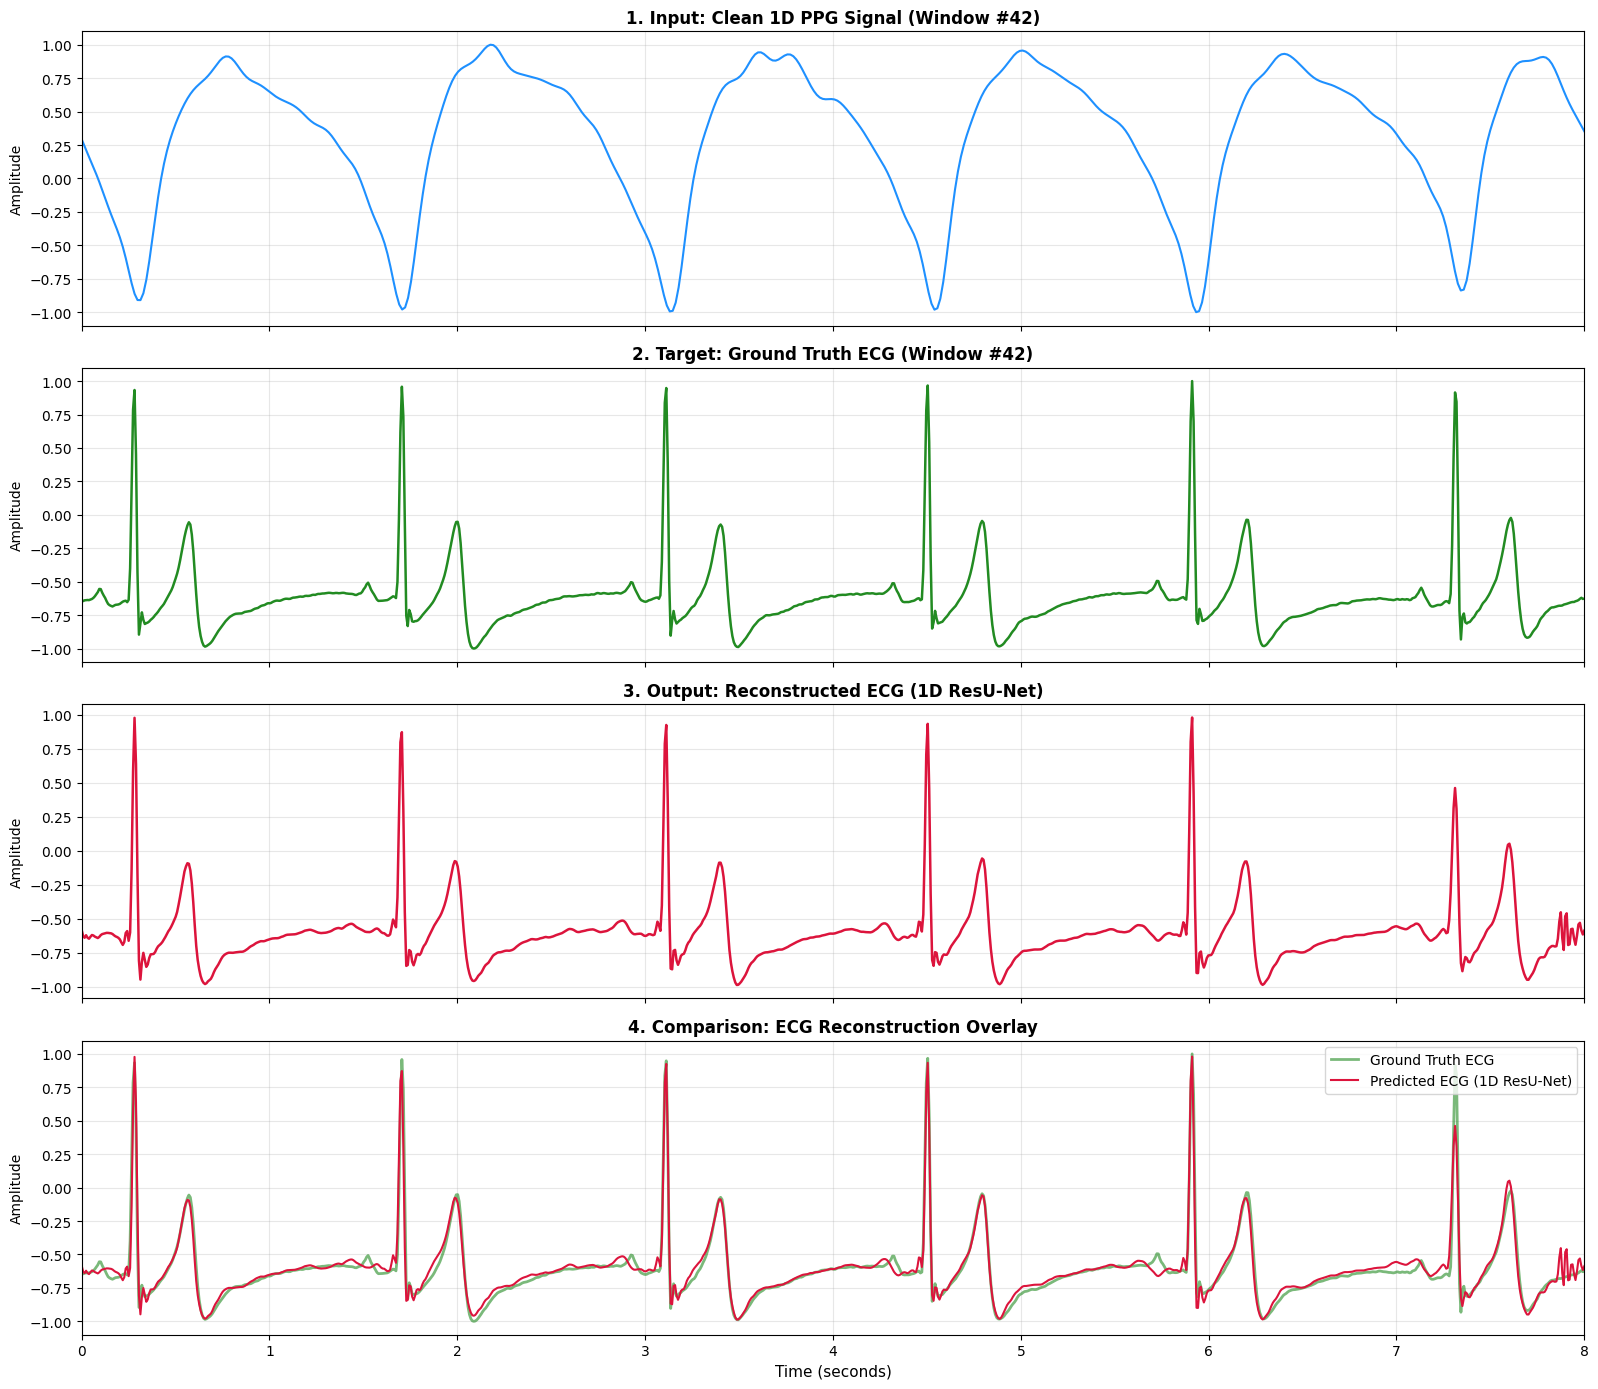

In [ ]:
# ==============================================================================
# CELL 9: VISUALIZATIONS (PPG, SEPARATE ECGs & OVERLAY)
# ==============================================================================
import matplotlib.pyplot as plt

# Choose any 8-second window to inspect
WINDOW_INDEX = 42

x_raw = X_data[WINDOW_INDEX].flatten()
y_true = y_data[WINDOW_INDEX].flatten()
y_pred_plot = all_preds[WINDOW_INDEX].flatten().numpy()

t_ppg = np.linspace(0, 8, len(x_raw))
t_ecg = np.linspace(0, 8, len(y_true))

# Create 4-panel figure
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# 1. Clean 1D PPG Input
axes[0].plot(t_ppg, x_raw, color='dodgerblue', linewidth=1.5)
axes[0].set_title(f"1. Input: Clean 1D PPG Signal (Window #{WINDOW_INDEX})", fontweight='bold', fontsize=12)
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# 2. Separate Ground Truth ECG
axes[1].plot(t_ecg, y_true, color='forestgreen', linewidth=1.8)
axes[1].set_title(f"2. Target: Ground Truth ECG (Window #{WINDOW_INDEX})", fontweight='bold', fontsize=12)
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

# 3. Separate Reconstructed ECG
axes[2].plot(t_ecg, y_pred_plot, color='crimson', linewidth=1.8)
axes[2].set_title(f"3. Output: Reconstructed ECG (1D ResU-Net)", fontweight='bold', fontsize=12)
axes[2].set_ylabel("Amplitude")
axes[2].grid(True, alpha=0.3)

# 4. Direct Overlay Comparison
axes[3].plot(t_ecg, y_true, color='forestgreen', alpha=0.6, linewidth=2.0, label='Ground Truth ECG')
axes[3].plot(t_ecg, y_pred_plot, color='crimson', linewidth=1.5, label='Predicted ECG (1D ResU-Net)')
axes[3].set_title("4. Comparison: ECG Reconstruction Overlay", fontweight='bold', fontsize=12)
axes[3].set_xlabel("Time (seconds)", fontsize=11)
axes[3].set_ylabel("Amplitude")
axes[3].set_xlim(0, 8)
axes[3].legend(loc='upper right', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()